# CSCE 40103 Module 4 - Assignment 3
## Malware Feature Clustering

**Dataset used:** staDynBenignLab, staDynVxHeaven2698Lab, staDynVt2955Lab

Date - Jun 20 2026
Name - Bryant Baum


## 1. Setup



In [23]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

BENIGN_CSV = Path("staDynBenignLab.csv")
VX_HEAVEN_CSV = Path("staDynVxHeaven2698Lab.csv")
VIRUS_TOTAL_CSV = Path("staDynVt2955Lab.csv")

RANDOM_STATE = 40103

print("Setup complete. No package installation or internet access required.")

Setup complete. No package installation or internet access required.


## Load the Dataset

Load the PDFMalware2022.csv into data_frame


In [24]:
def load_dataset(local_csv) -> pd.DataFrame:
    # Load the PDF malware dataset without internet or package installation.
    if local_csv.exists():
        print(f"Loading local CSV file: {local_csv}")
        loaded_df = pd.read_csv(local_csv)
        loaded_df.columns = loaded_df.columns.str.strip()
    else:
        print("Local CSV not found")

    return loaded_df

# shape of df_benign

In [25]:
df_benign = load_dataset(BENIGN_CSV)
df_benign["source_label"] = "benign"
df_benign["binary_label"] = "benign"
print("df_benign Dataset loaded successfully.")
print("Shape:", df_benign.shape)
df_benign.head()

Loading local CSV file: staDynBenignLab.csv
df_benign Dataset loaded successfully.
Shape: (595, 1089)


/var/folders/pr/t00ymn8d41n4ym_4rfyv0yl80000gn/T/ipykernel_40104/2507160884.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_benign["source_label"] = "benign"
/var/folders/pr/t00ymn8d41n4ym_4rfyv0yl80000gn/T/ipykernel_40104/2507160884.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_benign["binary_label"] = "benign"


,,filename,Virtual,Offset,loc,Import,Imports,var,Forwarder,UINT,LONG,BOOL,WORD,BYTES,large,short,dd,db,dw,XREF,ptr,DATA,FUNCTION,extrn,byte,word,dword,char,DWORD,stdcall,arg,locret,asc,align,WinMain,unk,cookie,off,nullsub,DllEntryPoint,System32,dll,CHUNK,BASS,HMENU,DLL,LPWSTR,void,HRESULT,HDC,...,compile_date,pointer_to_symbol_table,number_of_symbols,size_of_optional_header,characteristics,magic,major_linker_version,minor_linker_version,size_init_data,size_uninit_data,section_alignment,file_alignment,major_operating_system_version,minor_operating_system_version,major_image_version,minor_image_version,major_subsystem_version,minor_subsystem_version,size_of_headers,subsystem,dll_characteristics,loader_flags,number_of_imports.1,AddressOfEntryPoint,SizeOfHeaders.1,CheckSum,size_of_stack_reserve,size_of_stack_commit,size_of_heap_reserve,size_of_heap_commit,image_base,Size_image,BaseOfCode,number_of_rva_and_sizes.1,number_of_IAT_entires.1,count_mutex,files_operations,count_file_read,count_file_written,count_file_exists,count_file_deleted,count_file_copied,count_file_renamed,count_regkey_written,count_regkey_deleted,count_file_opened,count_dll_loaded,label,source_label,binary_label
0,0,005aea0582da91b95d44f616c7e1257f6b97514445970...,0,0,1,0,0,0,0,0,0,0,0,0,0,0,421,52,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1343268103,0,0,224,258,267,10,10,10240,0,4096,512,6,2,6,2,6,0,1024,2,33088,0,5,12810,1024,55744,262144.0,8192.0,1048576.0,4096.0,4194304.0,36864,4096,16,85.0,0,0,0,0,0,0,0,0,0,0,0,0,0,benign,benign
1,1,006bcbf75d4dcf4da65f5b89e4ed1a77c2733f1a8d80b...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,120,26,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1343269433,0,0,224,258,267,10,10,8192,0,4096,512,6,2,6,2,6,2,1024,3,33088,0,4,10505,1024,62768,262144.0,8192.0,1048576.0,4096.0,4194304.0,28672,4096,16,94.0,0,0,0,0,0,0,0,0,0,0,0,0,0,benign,benign
2,2,022fdc3d34c83da8b8905fa04047127f51d0023cdea32...,0,0,1,0,0,0,0,0,0,0,0,0,0,0,153,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,998081825,0,0,224,271,267,7,0,8704,0,4096,512,5,1,5,1,4,0,1024,3,32768,0,5,5442,1024,22559,262144.0,4096.0,1048576.0,4096.0,16777216.0,20480,4096,16,43.0,0,0,0,0,0,0,0,0,0,0,0,0,0,benign,benign
3,3,03877b98c8be5f43a6ab6e0e7dad493082897aceb8025...,0,0,1,0,0,0,0,0,0,0,0,0,0,0,765,62,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1247529729,0,0,224,258,267,9,0,10752,0,4096,512,6,1,6,1,6,1,1024,3,33088,0,7,19525,1024,72145,262144.0,8192.0,1048576.0,4096.0,16777216.0,40960,4096,16,108.0,0,0,0,0,0,0,0,0,0,0,0,0,0,benign,benign
4,4,04bc9c75612c5489ad943b31e4bf55827b47c25cd2583...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,266,25,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1343268044,0,0,224,258,267,10,10,7168,0,4096,512,6,2,6,2,6,2,1024,2,33088,0,5,9788,1024,44894,262144.0,8192.0,1048576.0,4096.0,4194304.0,32768,4096,16,78.0,0,0,0,0,0,0,0,0,0,0,0,0,0,benign,benign


# shape of df_vx

In [26]:
df_vx = load_dataset(VX_HEAVEN_CSV)
df_vx["source_label"] = "malware_vxheaven"
df_vx["binary_label"] = "malware"
print("df_vx Dataset loaded successfully.")
print("Shape:", df_vx.shape)
df_vx.head()

Loading local CSV file: staDynVxHeaven2698Lab.csv
df_vx Dataset loaded successfully.
Shape: (2698, 1089)


/var/folders/pr/t00ymn8d41n4ym_4rfyv0yl80000gn/T/ipykernel_40104/3657177597.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_vx["source_label"] = "malware_vxheaven"
/var/folders/pr/t00ymn8d41n4ym_4rfyv0yl80000gn/T/ipykernel_40104/3657177597.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_vx["binary_label"] = "malware"


,Virtual,Offset,loc,Import,Imports,var,Forwarder,UINT,LONG,BOOL,WORD,BYTES,large,short,dd,db,dw,XREF,ptr,DATA,FUNCTION,extrn,byte,word,dword,char,DWORD,stdcall,arg,locret,asc,align,WinMain,unk,cookie,off,nullsub,DllEntryPoint,System32,dll,CHUNK,BASS,HMENU,DLL,LPWSTR,void,HRESULT,HDC,LRESULT,HANDLE,...,compile_date,pointer_to_symbol_table,number_of_symbols,size_of_optional_header,characteristics,magic,major_linker_version,minor_linker_version,size_init_data,size_uninit_data,section_alignment,file_alignment,major_operating_system_version,minor_operating_system_version,major_image_version,minor_image_version,major_subsystem_version,minor_subsystem_version,size_of_headers,subsystem,dll_characteristics,loader_flags,number_of_imports.1,AddressOfEntryPoint,SizeOfHeaders.1,CheckSum,size_of_stack_reserve,size_of_stack_commit,size_of_heap_reserve,size_of_heap_commit,image_base,Size_image,BaseOfCode,number_of_rva_and_sizes.1,number_of_IAT_entires.1,count_mutex,files_operations,count_file_read,count_file_written,count_file_exists,count_file_deleted,count_file_copied,count_file_renamed,count_regkey_written,count_regkey_deleted,count_file_opened,count_dll_loaded,label,source_label,binary_label
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,129,19,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,560097138,0,0,224,33167,267,2,25,2048,0,4096,512,1,0,0,0,3,10,1024,3,0,0,2,4096,1024,0,1048576.0,8192.0,1048576.0,4096.0,4194304.0,20480,4096,16,0.0,0,0,0,0,0,0,0,0,0,0,0,0,1,malware_vxheaven,malware
1,0,0,3,0,0,0,0,0,0,0,0,0,0,0,306,84,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,55964,0,0,224,270,267,3,10,29696,0,4096,4096,4,0,0,0,4,0,1024,2,0,0,6,51868,1024,99428,1048576.0,4096.0,1048576.0,4096.0,4194304.0,55964,4096,16,144.0,0,0,0,0,0,0,0,0,0,0,0,0,1,malware_vxheaven,malware
2,0,0,7,0,0,0,0,0,0,0,0,0,0,0,1114,387,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,2557891634,0,0,224,271,267,6,0,72192,0,4096,512,4,0,0,0,4,0,1024,2,0,0,1,94391,1024,0,1048576.0,4096.0,1048576.0,4096.0,4194304.0,94791,4096,16,33.0,0,0,0,0,0,0,0,0,0,0,0,0,1,malware_vxheaven,malware
3,0,0,172,0,0,0,0,0,0,0,0,0,0,0,6385,1122,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,21,0,0,0,0,0,0,0,0,0,0,...,1213499312,0,0,224,271,267,6,0,12288,0,4096,4096,4,0,1,0,4,0,4096,2,0,0,1,5480,4096,505359,1048576.0,4096.0,1048576.0,4096.0,4194304.0,475136,4096,16,77.0,0,5,1,0,4,0,0,0,34,0,1,5,1,malware_vxheaven,malware
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,2013931587,0,0,224,33166,267,2,25,6144,0,4096,512,1,0,0,0,3,10,1423,2,0,0,2,664,1423,0,1048576.0,8192.0,1048576.0,4096.0,4194304.0,24576,4096,16,0.0,0,0,0,0,0,0,0,0,0,0,0,0,1,malware_vxheaven,malware


# shape of df_vt

In [27]:
df_vt = load_dataset(VIRUS_TOTAL_CSV)
df_vt["source_label"] = "malware_virustotal"
df_vt["binary_label"] = "malware"
print("df_vt Dataset loaded successfully.")
print("Shape:", df_vt.shape)
df_vt.head()

Loading local CSV file: staDynVt2955Lab.csv
df_vt Dataset loaded successfully.
Shape: (2955, 1090)


/var/folders/pr/t00ymn8d41n4ym_4rfyv0yl80000gn/T/ipykernel_40104/3112091182.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_vt["source_label"] = "malware_virustotal"
/var/folders/pr/t00ymn8d41n4ym_4rfyv0yl80000gn/T/ipykernel_40104/3112091182.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_vt["binary_label"] = "malware"


,filename,Virtual,Offset,loc,Import,Imports,var,Forwarder,UINT,LONG,BOOL,WORD,BYTES,large,short,dd,db,dw,XREF,ptr,DATA,FUNCTION,extrn,byte,word,dword,char,DWORD,stdcall,arg,locret,asc,align,WinMain,unk,cookie,off,nullsub,DllEntryPoint,System32,dll,CHUNK,BASS,HMENU,DLL,LPWSTR,void,HRESULT,HDC,LRESULT,...,compile_date,pointer_to_symbol_table,number_of_symbols,size_of_optional_header,characteristics,magic,major_linker_version,minor_linker_version,size_init_data,size_uninit_data,section_alignment,file_alignment,major_operating_system_version,minor_operating_system_version,major_image_version,minor_image_version,major_subsystem_version,minor_subsystem_version,size_of_headers,subsystem,dll_characteristics,loader_flags,number_of_imports.1,AddressOfEntryPoint,SizeOfHeaders.1,CheckSum,size_of_stack_reserve,size_of_stack_commit,size_of_heap_reserve,size_of_heap_commit,image_base,Size_image,BaseOfCode,number_of_rva_and_sizes.1,number_of_IAT_entires.1,count_mutex,files_operations,count_file_read,count_file_written,count_file_exists,count_file_deleted,count_file_copied,count_file_renamed,count_regkey_written,count_regkey_deleted,count_file_opened,count_dll_loaded,label,source_label,binary_label
0,0000fa4d5b6a06b20aebb76a2d46fa8c122d8e70566eda...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,227,147,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1329663709,0,0,224,783,267,2,22,20480,109568,4096,512,4,0,6,0,4,0,1024,2,32768,0,8,17191,1024,434547,2097152.0,4096.0,1048576.0,4096.0,4.194304e+06,245760,4096,16,0.0,0,0,0,0,0,0,0,0,0,0,0,0,1,malware_virustotal,malware
1,00050248396dab9852e60e8afaa265483a99ead18e6edc...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,555,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1342061809,0,0,224,258,267,9,0,335360,0,4096,512,5,0,0,0,5,0,1024,2,33088,0,4,12863,1024,390624,1048576.0,4096.0,1048576.0,4096.0,4.194304e+06,389120,4096,16,92.0,0,0,0,0,0,0,0,0,0,0,0,0,1,malware_virustotal,malware
2,0005a6d64cba0a220f5621ad17afa52f7413cfe9b158bf...,0,0,4,0,0,0,0,0,0,0,0,0,0,0,3069,792,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1208111689,0,0,224,271,267,7,10,16384,0,4096,512,5,1,5,1,4,0,4096,2,32768,0,7,105404,4096,182821,262144.0,4096.0,1048576.0,4096.0,1.677722e+07,167936,4096,16,186.0,0,1,1,0,0,0,0,0,0,0,1,1,1,malware_virustotal,malware
3,0006253243ffb8901f1493540fd5b9fc8144a7d3d59fb8...,0,0,130,0,0,0,0,0,0,0,0,0,0,0,9406,977,2,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,14,0,0,0,0,0,0,0,0,0,...,1422330987,0,0,224,271,267,6,0,4096,106496,4096,512,4,0,0,0,4,0,4096,2,0,0,4,149056,4096,0,1048576.0,4096.0,1048576.0,4096.0,4.194304e+06,159744,110592,16,0.0,0,3,1,0,1,0,0,0,0,0,1,4,1,malware_virustotal,malware
4,000d9c048778d192525053f87d35ba40b0b5f0e5acb50d...,0,0,42,0,0,0,0,0,0,0,0,0,0,0,1923,627,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1495659583,0,0,240,34,523,9,0,57344,0,4096,512,5,2,0,0,5,2,1024,2,33088,0,3,51884,1024,231597,1048576.0,4096.0,1048576.0,4096.0,5.368709e+09,208896,4096,16,182.0,0,0,0,0,0,0,0,0,0,0,0,0,1,malware_virustotal,malware


## combine the three datasets

In [28]:
df_combined_full = pd.concat([df_benign, df_vx, df_vt], ignore_index=True)

print("Combined dataset created.")
print("Shape:", df_combined_full.shape)

print("\nRows per source_label:")
print(df_combined_full["source_label"].value_counts())

print("\nRows per binary_label:")
print(df_combined_full["binary_label"].value_counts())

if "binary_label" in df_combined_full:
    df_combined_full["binary_label"] = df_combined_full["binary_label"].map({"malware": 1, "benign": 0})

df_combined_full.head()

Combined dataset created.
Shape: (6248, 1091)

Rows per source_label:
source_label
malware_virustotal    2955
malware_vxheaven      2698
benign                 595
Name: count, dtype: int64

Rows per binary_label:
binary_label
malware    5653
benign      595
Name: count, dtype: int64


,,filename,Virtual,Offset,loc,Import,Imports,var,Forwarder,UINT,LONG,BOOL,WORD,BYTES,large,short,dd,db,dw,XREF,ptr,DATA,FUNCTION,extrn,byte,word,dword,char,DWORD,stdcall,arg,locret,asc,align,WinMain,unk,cookie,off,nullsub,DllEntryPoint,System32,dll,CHUNK,BASS,HMENU,DLL,LPWSTR,void,HRESULT,HDC,...,number_of_symbols,size_of_optional_header,characteristics,magic,major_linker_version,minor_linker_version,size_init_data,size_uninit_data,section_alignment,file_alignment,major_operating_system_version,minor_operating_system_version,major_image_version,minor_image_version,major_subsystem_version,minor_subsystem_version,size_of_headers,subsystem,dll_characteristics,loader_flags,number_of_imports.1,AddressOfEntryPoint,SizeOfHeaders.1,CheckSum,size_of_stack_reserve,size_of_stack_commit,size_of_heap_reserve,size_of_heap_commit,image_base,Size_image,BaseOfCode,number_of_rva_and_sizes.1,number_of_IAT_entires.1,count_mutex,files_operations,count_file_read,count_file_written,count_file_exists,count_file_deleted,count_file_copied,count_file_renamed,count_regkey_written,count_regkey_deleted,count_file_opened,count_dll_loaded,label,source_label,binary_label,__vbaVarIndexLoad,SafeArrayPtrOfIndex
0,0.0,005aea0582da91b95d44f616c7e1257f6b97514445970...,0,0,1,0,0,0,0,0,0,0,0,0,0,0,421,52,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,224,258,267,10,10,10240,0,4096,512,6,2,6,2,6,0,1024,2,33088,0,5,12810,1024,55744,262144.0,8192.0,1048576.0,4096.0,4194304.0,36864,4096,16,85.0,0,0,0,0,0,0,0,0,0,0,0,0,0,benign,0,NaN,NaN
1,1.0,006bcbf75d4dcf4da65f5b89e4ed1a77c2733f1a8d80b...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,120,26,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,224,258,267,10,10,8192,0,4096,512,6,2,6,2,6,2,1024,3,33088,0,4,10505,1024,62768,262144.0,8192.0,1048576.0,4096.0,4194304.0,28672,4096,16,94.0,0,0,0,0,0,0,0,0,0,0,0,0,0,benign,0,NaN,NaN
2,2.0,022fdc3d34c83da8b8905fa04047127f51d0023cdea32...,0,0,1,0,0,0,0,0,0,0,0,0,0,0,153,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,224,271,267,7,0,8704,0,4096,512,5,1,5,1,4,0,1024,3,32768,0,5,5442,1024,22559,262144.0,4096.0,1048576.0,4096.0,16777216.0,20480,4096,16,43.0,0,0,0,0,0,0,0,0,0,0,0,0,0,benign,0,NaN,NaN
3,3.0,03877b98c8be5f43a6ab6e0e7dad493082897aceb8025...,0,0,1,0,0,0,0,0,0,0,0,0,0,0,765,62,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,224,258,267,9,0,10752,0,4096,512,6,1,6,1,6,1,1024,3,33088,0,7,19525,1024,72145,262144.0,8192.0,1048576.0,4096.0,16777216.0,40960,4096,16,108.0,0,0,0,0,0,0,0,0,0,0,0,0,0,benign,0,NaN,NaN
4,4.0,04bc9c75612c5489ad943b31e4bf55827b47c25cd2583...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,266,25,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,224,258,267,10,10,7168,0,4096,512,6,2,6,2,6,2,1024,2,33088,0,5,9788,1024,44894,262144.0,8192.0,1048576.0,4096.0,4194304.0,32768,4096,16,78.0,0,0,0,0,0,0,0,0,0,0,0,0,0,benign,0,NaN,NaN


# Explanation

- Labels should not be used when clustering features because they are non numeric and because they will train the data on the answers, therefore skewing the results. 

## 2: Data Cleaning and Feature Selection

Prepare a numeric feature matrix for clustering. Remove label columns and any identifier-like
columns.

### Drop initial columns
Remove file names, hashes, and identifiers from the feature matrix.
Source_label and binary_label excluded later

In [29]:
drop_cols = ["filename", "label","", " ", "compile_date"]
# need to ignore errors because not all cols exist for all sources
df_combined = df_combined_full.drop(columns=drop_cols, errors="ignore")
print(df_combined.shape)

(6248, 1087)


### Drop columns with too many missing values

In [30]:
# Calculate the percentage of missing values per column
missing_pct = df_combined.isnull().mean()

# Keep columns with less than 30% missing data
columns_to_keep = missing_pct[missing_pct < 0.30].index
df_combined = df_combined[columns_to_keep]
print(df_combined.shape)

(6248, 1087)


### Drop low variance columns

In [31]:
# Drop columns where all values are identical
unique_counts = df_combined.nunique()
df_combined = df_combined.loc[:, unique_counts > 1]
print(df_combined.shape)

(6248, 245)


### Identify feature correlation

In [32]:
df_integer_only = df_combined.drop(columns=['source_label']).copy()
# Create a correlation matrix
corr_matrix = df_integer_only.corr().abs()

# Select the upper triangle of the correlation matrix
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find columns with a correlation greater than 0.85
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.85)]

df_combined = df_combined.drop(columns=to_drop)

### Look at the remaining columns and decide which ones to keep 

In [33]:
print(df_combined.shape)
print('\nColumns:')
print(df_combined.columns.tolist())
print('\nData types:')
display(df_combined.dtypes.to_frame('dtype'))
df_combined.head(20)

(6248, 104)

Columns:
['loc', 'UINT', 'BOOL', 'dd', 'db', 'dw', 'ptr', 'byte', 'word', 'arg', 'align', 'cookie', 'off', 'dll', 'int', '.rdata:', '.data:', '.text:', 'proc', 'fs', 'gs', 'bt', 'call', 'cmc', 'faddp', 'fchs', 'fild', 'fld', 'fstcw', 'fxch', 'jl', 'jmp', 'mov', 'mul', 'neg', 'rcl', 'rdtsc', 'rep', 'ret', 'rol', 'sar', 'setb', 'setle', 'shl', 'sidt', 'stc', 'xor', 'nop', 'SetCursorPos', 'ShellExecuteA', 'GetFileAttributesA', 'rand', 'ent_whole_file', 'ent_mean', 'ent_var', 'ent_max', 'ent_min', 'filesize', 'number_of_IAT_entires', 'number_of_rva_and_sizes', 'size_code', 'SizeOfHeaders', 'machine', 'number_of_sections.1', 'pointer_to_symbol_table', 'number_of_symbols', 'characteristics', 'major_linker_version', 'minor_linker_version', 'size_init_data', 'size_uninit_data', 'section_alignment', 'file_alignment', 'major_operating_system_version', 'minor_operating_system_version', 'major_image_version', 'minor_image_version', 'major_subsystem_version', 'minor_subsystem_version',

,dtype
loc,int64
UINT,int64
BOOL,int64
dd,int64
db,int64
...,...
count_regkey_deleted,int64
count_file_opened,int64
count_dll_loaded,int64
source_label,str


,loc,UINT,BOOL,dd,db,dw,ptr,byte,word,arg,align,cookie,off,dll,int,.rdata:,.data:,.text:,proc,fs,gs,bt,call,cmc,faddp,fchs,fild,fld,fstcw,fxch,jl,jmp,mov,mul,neg,rcl,rdtsc,rep,ret,rol,sar,setb,setle,shl,sidt,stc,xor,nop,SetCursorPos,ShellExecuteA,...,ent_var,ent_max,ent_min,filesize,number_of_IAT_entires,number_of_rva_and_sizes,size_code,SizeOfHeaders,machine,number_of_sections.1,pointer_to_symbol_table,number_of_symbols,characteristics,major_linker_version,minor_linker_version,size_init_data,size_uninit_data,section_alignment,file_alignment,major_operating_system_version,minor_operating_system_version,major_image_version,minor_image_version,major_subsystem_version,minor_subsystem_version,subsystem,dll_characteristics,loader_flags,number_of_imports.1,AddressOfEntryPoint,CheckSum,size_of_stack_reserve,size_of_stack_commit,size_of_heap_reserve,size_of_heap_commit,Size_image,BaseOfCode,count_mutex,files_operations,count_file_read,count_file_written,count_file_exists,count_file_deleted,count_file_copied,count_regkey_written,count_regkey_deleted,count_file_opened,count_dll_loaded,source_label,binary_label
0,1,0,0,421,52,0,0,1,0,0,0,0,0,0,436,0,0,1,0,0,0,0,251,1,0,0,0,0,0,0,0,125,648,1,3,0,0,0,72,0,3,0,0,2,0,1,98,0,0,0,...,0.022814,2.739660,2.208557,57434,85.0,16,10752,1024,332,5,0,0,258,10,10,10240,0,4096,512,6,2,6,2,6,0,2,33088,0,5,12810,55744,262144.0,8192.0,1048576.0,4096.0,36864,4096,0,0,0,0,0,0,0,0,0,0,0,benign,0
1,0,0,0,120,26,0,0,0,0,0,0,0,0,0,170,0,0,1,0,0,3,0,351,0,0,0,0,0,0,0,0,44,308,0,2,0,0,0,34,0,0,0,0,0,0,0,47,0,0,0,...,0.008117,2.733124,2.346066,44420,94.0,16,8192,1024,332,5,0,0,258,10,10,8192,0,4096,512,6,2,6,2,6,2,3,33088,0,4,10505,62768,262144.0,8192.0,1048576.0,4096.0,28672,4096,0,0,0,0,0,0,0,0,0,0,0,benign,0
2,1,0,0,153,5,0,0,0,0,0,0,0,0,0,6,0,0,1,0,12,21,0,54,0,0,0,0,0,0,0,2,39,130,0,0,0,0,1,14,1,0,0,0,1,0,0,21,0,0,0,...,0.029404,2.710182,2.221808,20706,43.0,16,3072,1024,332,3,0,0,271,7,0,8704,0,4096,512,5,1,5,1,4,0,3,32768,0,5,5442,22559,262144.0,4096.0,1048576.0,4096.0,20480,4096,0,0,0,0,0,0,0,0,0,0,0,benign,0
3,1,0,0,765,62,0,0,0,0,0,0,0,0,0,446,0,0,1,0,24,72,0,365,18,0,0,0,0,0,0,10,158,879,0,2,0,0,1,77,0,25,0,0,6,0,0,164,2,0,0,...,0.008031,2.701594,2.378513,69110,108.0,16,19456,1024,332,4,0,0,258,9,0,10752,0,4096,512,6,1,6,1,6,1,3,33088,0,7,19525,72145,262144.0,8192.0,1048576.0,4096.0,40960,4096,0,0,0,0,0,0,0,0,0,0,0,benign,0
4,0,0,0,266,25,0,0,0,0,0,0,0,0,0,407,0,0,1,0,6,6,0,163,0,0,0,0,0,0,0,0,65,504,1,1,0,0,0,55,0,1,0,0,0,0,0,74,0,0,0,...,0.017237,2.752913,2.283647,39574,78.0,16,8192,1024,332,6,0,0,258,10,10,7168,0,4096,512,6,2,6,2,6,2,2,33088,0,5,9788,44894,262144.0,8192.0,1048576.0,4096.0,32768,4096,0,0,0,0,0,0,0,0,0,0,0,benign,0
5,7,0,0,2564,103,10,0,0,0,0,0,0,0,0,622,0,0,1,0,38,58,0,475,0,0,0,1,0,0,0,43,209,1069,0,2,0,0,17,120,0,2,0,0,8,0,0,93,4,0,0,...,0.033073,2.751664,2.228936,97890,79.0,16,28672,1024,332,3,0,0,271,7,10,5120,0,4096,512,5,2,5,2,5,0,3,32768,0,6,24583,63187,262144.0,8192.0,1048576.0,4096.0,40960,4096,0,0,0,0,0,0,0,0,0,0,0,benign,0
6,0,0,0,1415,85,0,0,1,0,0,0,0,0,0,456,0,0,1,0,0,8,0,315,0,0,0,0,0,0,0,0,111,861,0,4,0,0,0,90,0,21,0,0,0,0,0,167,0,0,0,...,0.027740,2.724341,2.177518,71640,78.0,16,17920,1024,332,5,0,0,258,10,10,8192,0,4096,512,6,2,6,2,6,2,3,33088,0,5,20233,33304,262144.0,8192.0,1048576.0,4096.0,40960,4096,0,0,0,0,0,0,0,0,0,0,0,benign,0
7,1,0,0,808,104,4,0,0,0,0,0,0,0,0,534,0,0,1,0,37,67,0,443,0,0,0,1,0,0,0,35,140,936,3,41,0,0,25,109,0,0,0,0,2,0,1,109,0,0,0,...,0.032116,2.739550,1.974258,69440,84.0,16,20480,4096,332,3,0,0,271,7,10,12288,0,4096,4096,5,1,5,1,4,0,2,32768,0,7,10098,75614,262144.0,4096.0,1048576.0,4096.0,36864,4096,0,0,0,0,0,0,0,0,0,0,0,benign,0
8,0,0,0,213,41,0,0,0,0,0,0,0,0,0,366,0,0,1,0,0,0,0,230,0,0,0,0,0,0,0,1,67,459,1,1,0,0,0,51,0,0,0,0,0,0,0,66,0,0,0,...,0.037527,2.844363,2.138362,181534,114.0,16,7680,1024,332,5,0,0,258,10,10,64000,0,4096,512,6,2,6,2,6,2,2,33088,0,10,10115,92873,262144.0,8192.0,1048576.0,4096.0,86016,4096,0,0,0,0,0,0,0,0,0,0,0,benign,0
9,3

In [34]:
features_keep = [
    "filesize", 
    "number_of_IAT_entires",
    "size_code",
    "size_init_data",
    "Size_image",
    "BaseOfCode",
    "files_operations",
    "dd",
    "db",
    "ret",
    "rol",
    "sar",
    "shl",
    "xor",
    "nop",
    "size_of_stack_reserve",
    "size_of_stack_commit"
]

# Create a new df that has the features I want plus binary label
# Will separate binary label later
work = df_combined[features_keep].copy()
work["binary_label"] = df_combined_full["binary_label"].values
work["source_label"] = df_combined_full["source_label"].values
print(work.shape)
work.head()


(6248, 19)


,filesize,number_of_IAT_entires,size_code,size_init_data,Size_image,BaseOfCode,files_operations,dd,db,ret,rol,sar,shl,xor,nop,size_of_stack_reserve,size_of_stack_commit,binary_label,source_label
0,57434,85.0,10752,10240,36864,4096,0,421,52,72,0,3,2,98,0,262144.0,8192.0,0,benign
1,44420,94.0,8192,8192,28672,4096,0,120,26,34,0,0,0,47,0,262144.0,8192.0,0,benign
2,20706,43.0,3072,8704,20480,4096,0,153,5,14,1,0,1,21,0,262144.0,4096.0,0,benign
3,69110,108.0,19456,10752,40960,4096,0,765,62,77,0,25,6,164,2,262144.0,8192.0,0,benign
4,39574,78.0,8192,7168,32768,4096,0,266,25,55,0,1,0,74,0,262144.0,8192.0,0,benign


### Check Missing Values and Duplicate Rows

Check whether the dataset contains missing values and duplicate rows and then remove duplicates

In [35]:
missing_summary = work.isna().sum().sort_values(ascending=False)
duplicate_count = work.duplicated().sum()

print('Duplicate rows:', duplicate_count)
print('\nMissing values:')
display(missing_summary[missing_summary > 0].to_frame('missing_count'))

if missing_summary.sum() == 0:
    print('No missing values found.')

Duplicate rows: 224

Missing values:


,missing_count


No missing values found.


In [36]:
work = work.drop_duplicates(ignore_index=True)
duplicate_count = work.duplicated().sum()
print('Duplicate rows:', duplicate_count)

Duplicate rows: 0


### Feature summary

In [37]:
def feature_summary(feature, reason, meaning):
    return {
        "Feature": feature,
        "Reason for Keeping It": reason,
        "Possible Malware-Analysis Meaning": meaning
    }

summary_rows = []
for feature in features_keep:
    if feature == "dd" or feature == "db":
        summary_rows.append(feature_summary(feature, "Data directives that can give insight into file", "Can indicate packing, encryption, obfuscation"))
    elif feature == "xor" or feature == "ret" or feature == "nop":
        summary_rows.append(feature_summary(feature, "Assembly instructions", "High/low frequencies can indicate malware"))
    elif feature == "filesize" or feature == "size_code" or feature == "files_operations":
        summary_rows.append(feature_summary(feature, "Insight into file structure and behavior", "Abnormal structure behavior indicative of malware"))
    else:
        summary_rows.append(feature_summary(feature, "Randomly chose on visual inspection from remaining columns", "File characteristic"))

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,Feature,Reason for Keeping It,Possible Malware-Analysis Meaning
0,filesize,Insight into file structure and behavior,Abnormal structure behavior indicative of malware
1,number_of_IAT_entires,Randomly chose on visual inspection from remai...,File characteristic
2,size_code,Insight into file structure and behavior,Abnormal structure behavior indicative of malware
3,size_init_data,Randomly chose on visual inspection from remai...,File characteristic
4,Size_image,Randomly chose on visual inspection from remai...,File characteristic
5,BaseOfCode,Randomly chose on visual inspection from remai...,File characteristic
6,files_operations,Insight into file structure and behavior,Abnormal structure behavior indicative of malware
7,dd,Data directives that can give insight into file,"Can indicate packing, encryption, obfuscation"
8,db,Data directives that can give insight into file,"Can indicate packing, encryption, obfuscation"
9,ret,Assembly instructions,High/low frequencies can indicate malware


# 3. Scale Features

### Separate X and y

In [38]:
X = work[features_keep].copy()
y = work[["binary_label", "source_label"]].copy()

In [39]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()

,filesize,number_of_IAT_entires,size_code,size_init_data,Size_image,BaseOfCode,files_operations,dd,db,ret,rol,sar,shl,xor,nop,size_of_stack_reserve,size_of_stack_commit
0,-0.375852,-0.011930,-0.028812,-0.153620,-0.240335,-0.126126,-0.143568,-0.264187,-0.270721,-0.263954,-0.097126,-0.291097,-0.297765,-0.216030,-0.188926,-0.488182,-0.021056
1,-0.378696,0.058465,-0.028918,-0.154917,-0.242627,-0.126126,-0.143568,-0.272379,-0.275633,-0.276203,-0.097126,-0.304359,-0.305462,-0.221484,-0.188926,-0.488182,-0.021056
2,-0.383879,-0.340437,-0.029132,-0.154593,-0.244919,-0.126126,-0.143568,-0.271481,-0.279601,-0.282650,-0.094940,-0.304359,-0.301614,-0.224264,-0.188926,-0.488182,-0.108825
3,-0.373301,0.167967,-0.028449,-0.153296,-0.239189,-0.126126,-0.143568,-0.254825,-0.268831,-0.262343,-0.097126,-0.193845,-0.282370,-0.208972,-0.188238,-0.488182,-0.021056
4,-0.379755,-0.066681,-0.028918,-0.155566,-0.241481,-0.126126,-0.143568,-0.268406,-0.275822,-0.269434,-0.097126,-0.299939,-0.305462,-0.218596,-0.188926,-0.488182,-0.021056


### Generate feature histograms

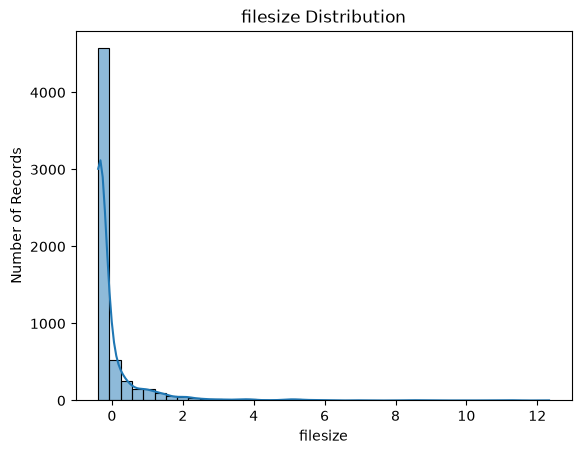

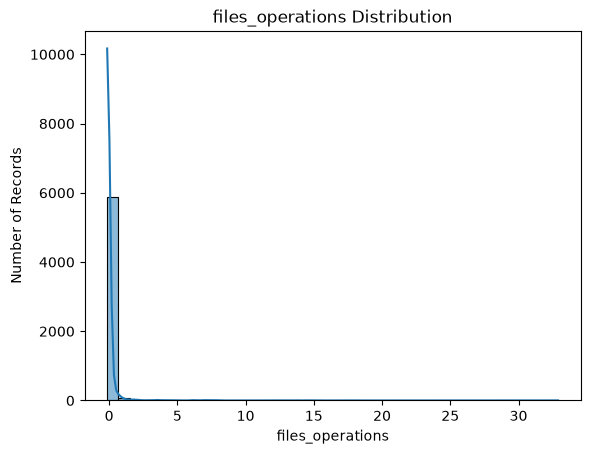

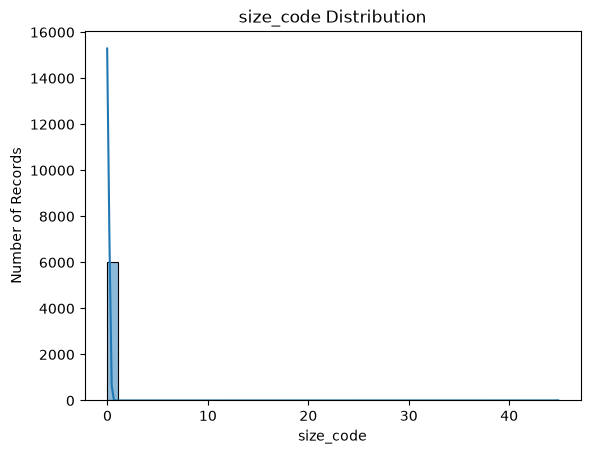

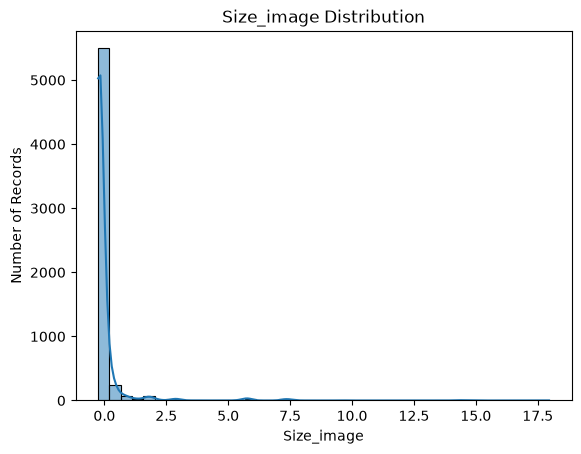

In [40]:
features_to_plot = ["filesize", "files_operations", "size_code", "Size_image"]
for feature in features_to_plot:
    if feature in X_scaled_df:
        sns.histplot(data=X_scaled_df, x=feature, bins=40, kde=True)
        plt.title(feature + " Distribution")
        plt.xlabel(feature)
        plt.ylabel("Number of Records")
        plt.show()

### Correlation heatmap

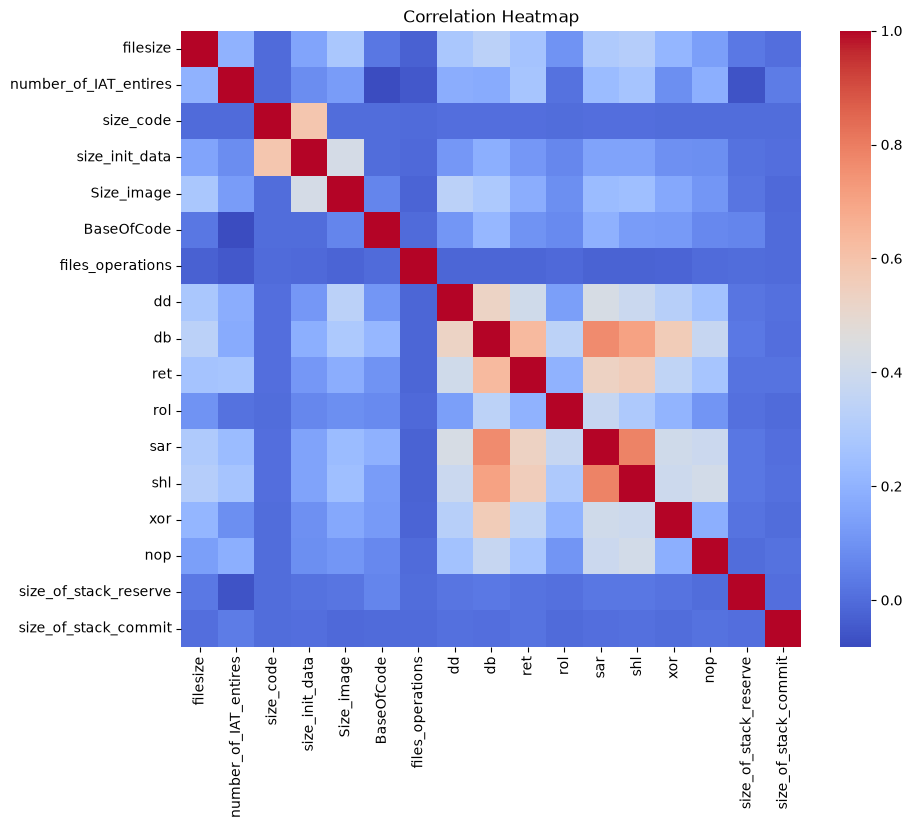

In [41]:
corr_phish = X_scaled_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_phish, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### 2D PCA visualization colored by binary_label (for interpretation only)

Explained variance ratio: [0.26466361 0.09681176]


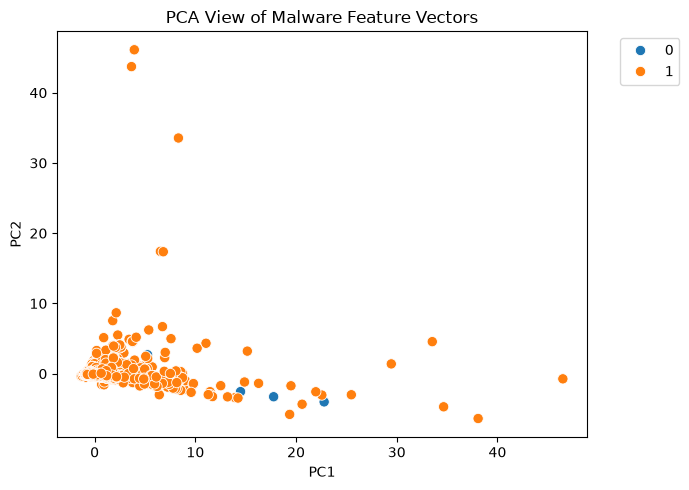

In [42]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

label_col = "binary_label"
if label_col:
    pca_df[label_col] = y["binary_label"].astype(str).values

print("Explained variance ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(7, 5))
if label_col:
    sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue=label_col, s=55)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
else:
    sns.scatterplot(data=pca_df, x="PC1", y="PC2", s=55)
plt.title("PCA View of Malware Feature Vectors")
plt.tight_layout()
plt.show()

# Interpretation
- There is a strong correlation between number_of_IAT_entires and BaseOfCode
- There is a strong correlation between number_of_IAT_entires and size_of_stack_reserve
- files_operations has a pretty strong correlation with all features
- dd, db, ret, rol, sar, shl, xor are not strongly correlated. 
- Features appear to not form any clear clusters based on the PCA view

## 4. K-Means Clustering
note: 
- X_scaled is what I want to be using
- X is the non-scaled clean dataset without binary_label
- y is binary label column 

### Get Silhouette score for k_ranges between 2 and 10

In [836]:
def evaluate_k_range(X_scaled, k_values, random_state=RANDOM_STATE):
    rows = []
    for k in k_values:
        model = KMeans(
            n_clusters=k,
            max_iter=300,
            n_init=20,
            random_state=random_state
        )
        labels = model.fit_predict(X_scaled)
        inertia = model.inertia_
        sil = np.nan
        if k >= 2:
            sil = silhouette_score(X_scaled, labels)
        rows.append({'K': k, 'inertia': inertia, 'silhouette': sil})
    return pd.DataFrame(rows)

k_values = range(2, 11)
k_eval = evaluate_k_range(X_scaled, k_values, RANDOM_STATE)
display(k_eval.round(3))

,K,inertia,silhouette
0,2,87132.805,0.742
1,3,79039.729,0.736
2,4,71571.772,0.677
3,5,67083.651,0.678
4,6,63036.052,0.699
5,7,57851.924,0.703
6,8,54770.360,0.643
7,9,49617.421,0.707
8,10,45762.715,0.686


### Graph elbow plot
- Inertia plot
- Silhouette plot

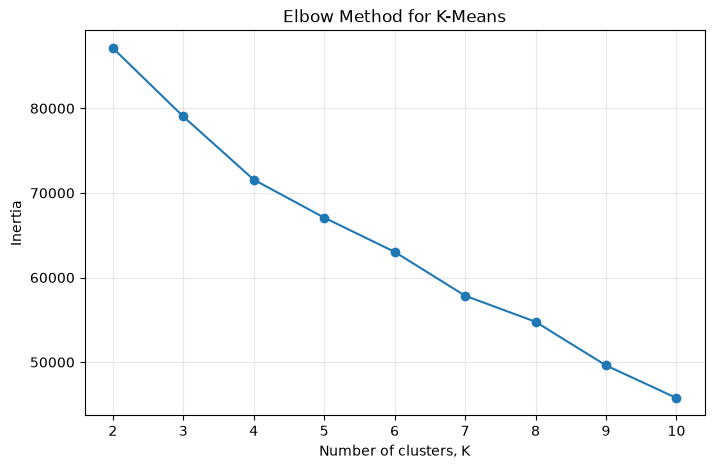

In [837]:
plt.figure(figsize=(8, 5))
plt.plot(k_eval['K'], k_eval['inertia'], marker='o')
plt.xlabel('Number of clusters, K')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-Means')
plt.xticks(k_eval['K'])
plt.grid(True, alpha=0.3)
plt.show()

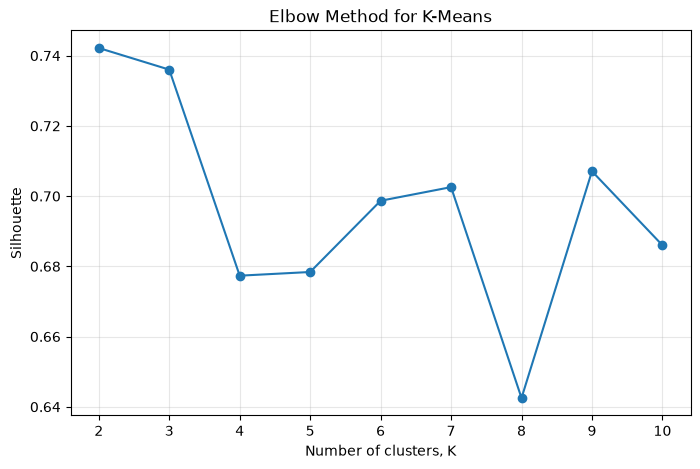

In [838]:
plt.figure(figsize=(8, 5))
plt.plot(k_eval['K'], k_eval['silhouette'], marker='o')
plt.xlabel('Number of clusters, K')
plt.ylabel('Silhouette')
plt.title('Elbow Method for K-Means')
plt.xticks(k_eval['K'])
plt.grid(True, alpha=0.3)
plt.show()

# Explanation
- Inertia does not have a sharp elbow, so basing off of the silhouette graph a k=2 is probably the best starting point

Chosen K: 2
Cluster sizes:
0    5672
1     352
Name: count, dtype: int64

Silhouette score: 0.742


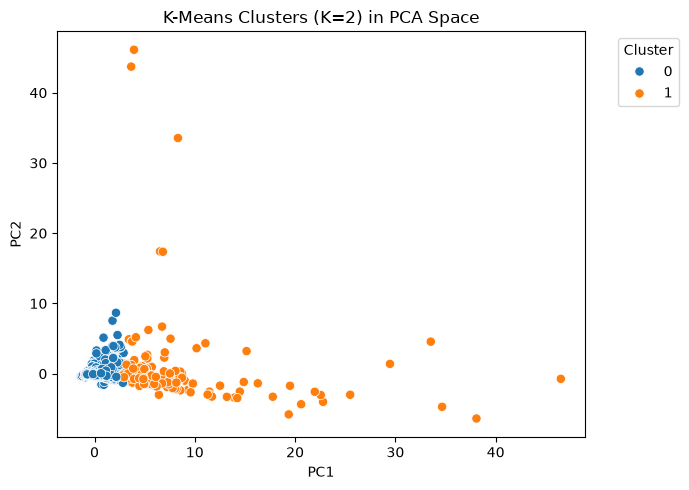

In [839]:
CHOSEN_K = 2
print("Chosen K:", CHOSEN_K)

final_kmeans = KMeans(
    n_clusters=CHOSEN_K,
    max_iter=300,
    n_init=20,
    random_state=RANDOM_STATE
)
cluster_labels = final_kmeans.fit_predict(X_scaled)

# cluster sizes
print("Cluster sizes:")
print(pd.Series(cluster_labels).value_counts().sort_index())
print("\nSilhouette score:", round(silhouette_score(X_scaled, cluster_labels), 3))

# reuse the existing PCA coords (same X_scaled rows, so aligned)
plot_df = pca_df.copy()
plot_df["kmeans_cluster"] = cluster_labels.astype(str)

plt.figure(figsize=(7, 5))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="kmeans_cluster", s=45)
plt.title(f"K-Means Clusters (K={CHOSEN_K}) in PCA Space")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [840]:
comments = {
    2: "Highest silhouette score and inertia",
    3: "Silhouette very close to 2, fairly large drop of inertia",
    4: "Large silhouette drop and another consistent drop of inertia",
    5: "Small silhouette and inertia drop"
}
k_table = k_eval.round(3)
k_table['Comments'] = k_eval["K"].map(comments)
k_table = k_table[k_table["K"].between(2,5)]
display(k_table)

,K,inertia,silhouette,Comments
0,2,87132.805,0.742,Highest silhouette score and inertia
1,3,79039.729,0.736,"Silhouette very close to 2, fairly large drop ..."
2,4,71571.772,0.677,Large silhouette drop and another consistent d...
3,5,67083.651,0.678,Small silhouette and inertia drop


# Explanation
- If I change the k from 2 the additional clusters are not meaningfully large, with k = 2 there is already a pretty big split with the cluster sizes of 5672 and 352, adding more clusters only makes small clusters between ~ 3-20

## 5. Hierarchical Clustering and Linkage Comparison
Use hierarchical clustering to inspect relationships among samples

### DENDOGRAM

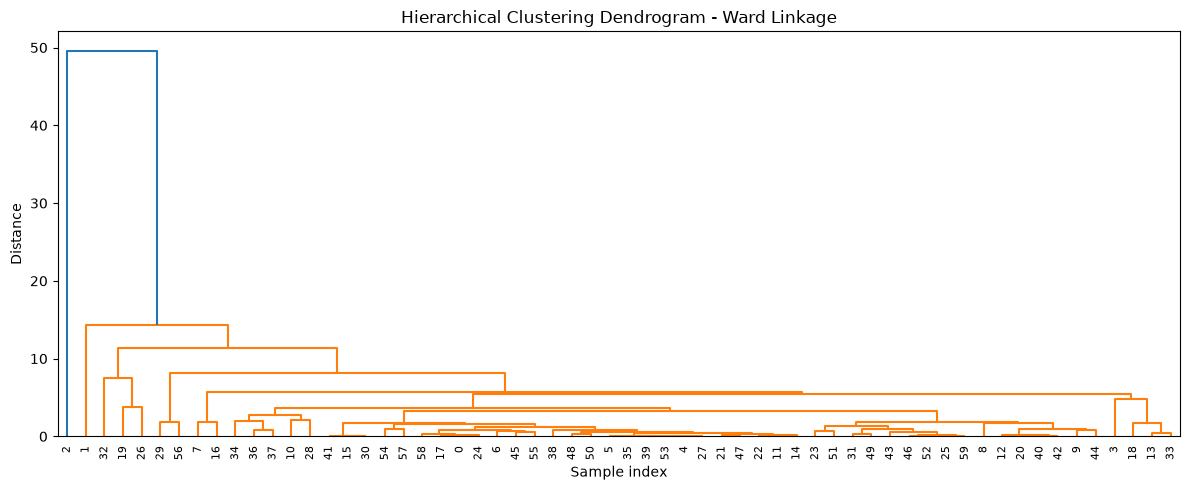

In [841]:
max_points_for_dendrogram = 60
sample_df = X_scaled_df.copy()

if len(sample_df) > max_points_for_dendrogram:
    sample_df = sample_df.sample(max_points_for_dendrogram, random_state=RANDOM_STATE)

Z = linkage(sample_df, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering Dendrogram - Ward Linkage")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

### AGGLOMERATIVE CLUSTERING
Using single, complete, average, and ward linkage

,linkage,k,silhouette_score
18,average,2,0.952358
27,single,2,0.952358
9,complete,2,0.952358
28,single,3,0.939787
19,average,3,0.939787
10,complete,3,0.924891
20,average,4,0.924723
21,average,5,0.920633
29,single,4,0.910151
31,single,6,0.910125


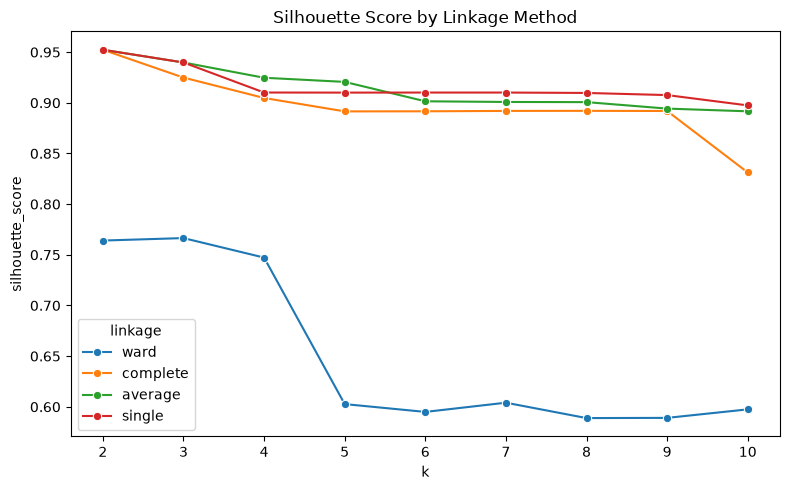

In [842]:
linkage_results = []

for linkage_name in ["ward", "complete", "average", "single"]:
    for k in range(2, 11):
        model = AgglomerativeClustering(n_clusters=k, linkage=linkage_name)
        labels = model.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        linkage_results.append({
            "linkage": linkage_name,
            "k": k,
            "silhouette_score": score
        })

linkage_df = pd.DataFrame(linkage_results)
display(linkage_df.sort_values("silhouette_score", ascending=False).head(10))

plt.figure(figsize=(8, 5))
sns.lineplot(data=linkage_df, x="k", y="silhouette_score", hue="linkage", marker="o")
plt.title("Silhouette Score by Linkage Method")
plt.tight_layout()
plt.show()

| Linkage Method | K | Silhouette Score | Interpretation | 
| --- | --- | --- | --- | 
| Single | 2 | .9523 | Nearest cross-cluster pair | 
| Complete | 2 | .9523 | Farthest cross-cluster pair | 
| Average | 2 | .9523 | Average cross-cluster distance | 
| Ward | 2 | .7664 | Compact clusters with lower within-cluster spread | 

- The ward linkage is lower, but the other ones are so high because the cluster is so dense. The ward linkage is actually trying to break up that dense cluster. 

## 6. DBSCAN Clustering 

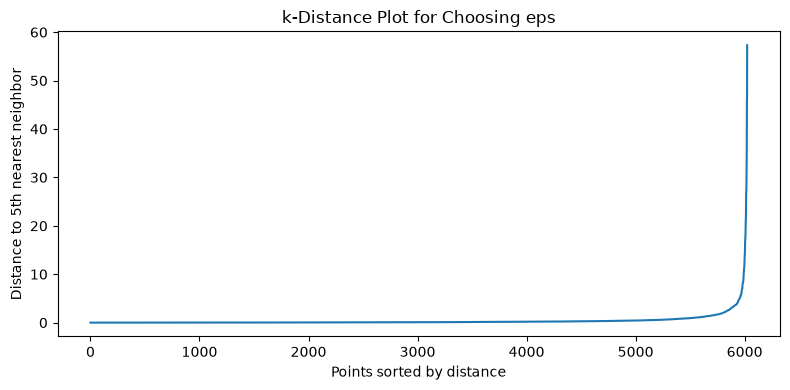

Suggested starting eps values to try:
[0.367 0.505 0.795 1.549]


In [843]:
min_samples = 5

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_scaled)
distances, indices = neighbors.kneighbors(X_scaled)

k_distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.title("k-Distance Plot for Choosing eps")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.tight_layout()
plt.show()

print("Suggested starting eps values to try:")
print(np.round(np.percentile(k_distances, [80, 85, 90, 95]), 3))

In [844]:

eps_values = np.round(np.percentile(k_distances, [80, 85, 90, 95]), 3)
min_samples_values = [5, 15, 25, 40]   

rows = []
for ms in min_samples_values:
    for ep in eps_values:
        labels = DBSCAN(eps=float(ep), min_samples=ms).fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = int((labels == -1).sum())
        noise_rate = n_noise / len(labels)
        mask = labels != -1
        if len(set(labels[mask])) >= 2:                       
            sil = silhouette_score(X_scaled[mask], labels[mask])
        else:
            sil = np.nan
        rows.append({
            "eps": ep,
            "min_points": ms,
            "clusters": n_clusters,
            "noise_rate": round(noise_rate, 3),
            "silhouette": round(sil, 3) if sil == sil else np.nan,
        })

sweep_df = pd.DataFrame(rows)
display(sweep_df.sort_values("silhouette", ascending=False).head(5))

,eps,min_points,clusters,noise_rate,silhouette
9,0.505,25,2,0.257,0.853
5,0.505,15,10,0.217,0.672
7,1.549,15,9,0.078,0.665
11,1.549,25,5,0.101,0.661
10,0.795,25,6,0.170,0.651


# EPS comments
- 0.505, 25, 2, .257: With only two clusters, this one is kind of cheating the silhouette score by throwing away a lot of the data. 
- 0.505, 15, 10, .217: More clusters, but still a pretty high noise rate
- 1.549, 25, 5, .101; Captures more of the data, has a lower silhouette score, but is a better representation of the data. 

### Visualize a particular DBSCAN
Pick a setting with at least two clusters and an acceptable noise rate, favoring the best valid silhouette, then plot it in PCA space.

chosen eps:  1.549
chosen min samples:  25

Cluster sizes (-1 = noise):
-1     606
 0    5274
 1      46
 2      36
 3      25
 4      37
Name: count, dtype: int64


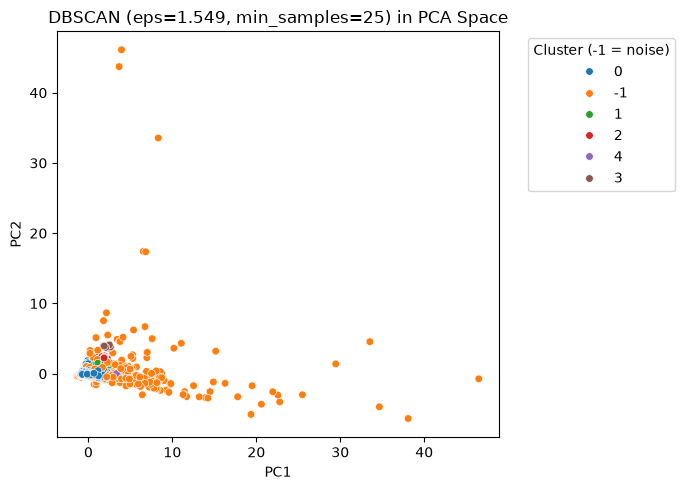

In [845]:
chosen_eps = 1.549
chosen_ms = 25
print("chosen eps: ", chosen_eps)
print("chosen min samples: ", chosen_ms)

# visualize the selected DBSCAN result in PCA space
final_labels = DBSCAN(eps=chosen_eps, min_samples=chosen_ms).fit_predict(X_scaled)
print("\nCluster sizes (-1 = noise):")
print(pd.Series(final_labels).value_counts().sort_index())

plot_df = pca_df.copy()
plot_df["dbscan_cluster"] = final_labels.astype(str)

plt.figure(figsize=(7, 5))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="dbscan_cluster", s=30)
plt.title(f"DBSCAN (eps={chosen_eps}, min_samples={chosen_ms}) in PCA Space")
plt.legend(title="Cluster (-1 = noise)", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Explanation

- core points are the root of a cluster, has at least min_samples neighbors in eps distance.

- border points sit within eps distance of a core point, but does not have enough min_samples neighbors of it's own to become a core point. 

- noise points are not within eps distance and do not have enough min_samples neighbors to qualify as a border point or a core point and is therefore left unassigned to any cluster


# 7. Cluster Evaluation and Label Comparison

In [846]:
km_labels   = KMeans(n_clusters=CHOSEN_K, n_init=20, max_iter=300,
                     random_state=RANDOM_STATE).fit_predict(X_scaled)
hier_labels = AgglomerativeClustering(n_clusters=2, linkage="ward").fit_predict(X_scaled)
db_labels_f = DBSCAN(eps=chosen_eps, min_samples=chosen_ms).fit_predict(X_scaled)

print("K-Means (K=2) silhouette:           ", round(silhouette_score(X_scaled, km_labels), 3))
print("Hierarchical (Ward, K=2) silhouette:", round(silhouette_score(X_scaled, hier_labels), 3))

mask = db_labels_f != -1
print("DBSCAN silhouette (non-noise):      ", round(silhouette_score(X_scaled[mask], db_labels_f[mask]), 3))

K-Means (K=2) silhouette:            0.742
Hierarchical (Ward, K=2) silhouette: 0.764
DBSCAN silhouette (non-noise):       0.661


In [847]:
for name, labels in [("KMeans", km_labels), ("Hierarchical", hier_labels), ("DBSCAN", db_labels_f)]:
    print(f"{name}: CLUSTER vs BINARY LABEL")
    display(pd.crosstab(labels, y["binary_label"].values, rownames=[name], colnames=["binary_label"]))
    print(f"{name}: CLUSTER vs SOURCE LABEL")
    display(pd.crosstab(labels, y["source_label"].values, rownames=[name], colnames=["source_label"]))
    print("---------------------------------")

KMeans: CLUSTER vs BINARY LABEL


binary_label,0,1
KMeans,,
0,584,5088
1,11,341


KMeans: CLUSTER vs SOURCE LABEL


source_label,benign,malware_virustotal,malware_vxheaven
KMeans,,,
0,584,2410,2678
1,11,331,10


---------------------------------
Hierarchical: CLUSTER vs BINARY LABEL


...

---------------------------------
DBSCAN: CLUSTER vs BINARY LABEL


binary_label,0,1
DBSCAN,,
-1,30,576
0,565,4709
1,0,46
2,0,36
3,0,25
4,0,37


DBSCAN: CLUSTER vs SOURCE LABEL


source_label,benign,malware_virustotal,malware_vxheaven
DBSCAN,,,
-1,30,482,94
0,565,2115,2594
1,0,46,0
2,0,36,0
3,0,25,0
4,0,37,0


---------------------------------


# Label Alignment Comments
- K-Means : malware_virustotal dominates the clusters, because the cluster was so dense it was almost chance that the small number of benign ended up with the rest of malware. 
- Hierarchical : Similar to kmeans virustotal dominates the cluster, once again indicating a separation in data instead of a separation on label. 
- DBSCAN : This one had 5 non-noise clusters. This one is probably the most informative to me since it really shows how the benign data was so densely compacted with the malware as all non-noise benign ended up in the same cluster as most of the virus points. The remaining clusters clean up the remaining virustotal data points that were not a part of the dense cluster. 

# 8. Cluster Profile Analysis

In [848]:
for name, labels in [("KMeans", km_labels), ("Hierarchical", hier_labels), ("DBSCAN", db_labels_f)]:
    prof = X.copy()
    prof["cluster"] = labels
    print(f"\n{name}: MEDIAN FEATURE PROFILE PER CLUSTER")
    display(prof.groupby("cluster").median().round(1))


KMeans: MEDIAN FEATURE PROFILE PER CLUSTER


,filesize,number_of_IAT_entires,size_code,size_init_data,Size_image,BaseOfCode,files_operations,dd,db,ret,rol,sar,shl,xor,nop,size_of_stack_reserve,size_of_stack_commit
cluster,,,,,,,,,,,,,,,,,
0,204303.0,43.0,26112.0,16384.0,106496.0,4096.0,0.0,965.0,132.0,95.0,0.0,4.0,6.0,170.5,18.0,1048576.0,4096.0
1,6153574.0,150.0,811008.0,628736.0,2330624.0,4096.0,0.0,52847.0,10288.5,5543.0,95.0,481.0,586.5,12893.0,2327.0,1048576.0,4096.0



Hierarchical: MEDIAN FEATURE PROFILE PER CLUSTER


,filesize,number_of_IAT_entires,size_code,size_init_data,Size_image,BaseOfCode,files_operations,dd,db,ret,rol,sar,shl,xor,nop,size_of_stack_reserve,size_of_stack_commit
cluster,,,,,,,,,,,,,,,,,
0,223231.0,46.0,28672.0,17408.0,110592.0,4096.0,0.0,1041.5,143.5,99.0,0.0,5.0,6.0,187.0,20.0,1048576.0,4096.0
1,6153574.0,92.0,811008.0,254464.0,2467840.0,4096.0,0.0,72358.5,15143.5,5961.0,404.0,570.5,578.0,17586.0,3163.5,1048576.0,4096.0



DBSCAN: MEDIAN FEATURE PROFILE PER CLUSTER


,filesize,number_of_IAT_entires,size_code,size_init_data,Size_image,BaseOfCode,files_operations,dd,db,ret,rol,sar,shl,xor,nop,size_of_stack_reserve,size_of_stack_commit
cluster,,,,,,,,,,,,,,,,,
-1,3798488.0,92.0,581632.0,248832.0,1609728.0,4096.0,0.0,24661.5,5232.0,2602.5,34.5,237.0,275.0,6478.0,1046.0,1048576.0,4096.0
0,175825.0,38.0,23552.0,14336.0,94208.0,4096.0,0.0,794.5,116.0,86.0,0.0,4.0,5.0,144.0,15.0,1048576.0,4096.0
1,7104884.0,102.0,543744.0,1804544.0,7278592.0,4096.0,1.0,117549.0,1462.5,923.0,22.0,65.0,112.0,2149.5,300.0,1048576.0,4096.0
2,4036172.0,276.0,294656.0,1122816.0,21528576.0,4096.0,2.0,37431.0,1350.0,808.0,29.0,73.5,123.0,1807.0,237.0,1048576.0,4096.0
3,11139782.0,112.0,261632.0,3411456.0,27152384.0,4096.0,0.0,24232.0,1543.0,655.0,28.0,75.0,128.0,1841.0,252.0,1048576.0,4096.0
4,9127216.0,505.0,800256.0,782336.0,1617920.0,4096.0,0.0,28156.0,4844.0,4038.0,0.0,481.0,650.0,6082.0,240.0,1048576.0,4096.0


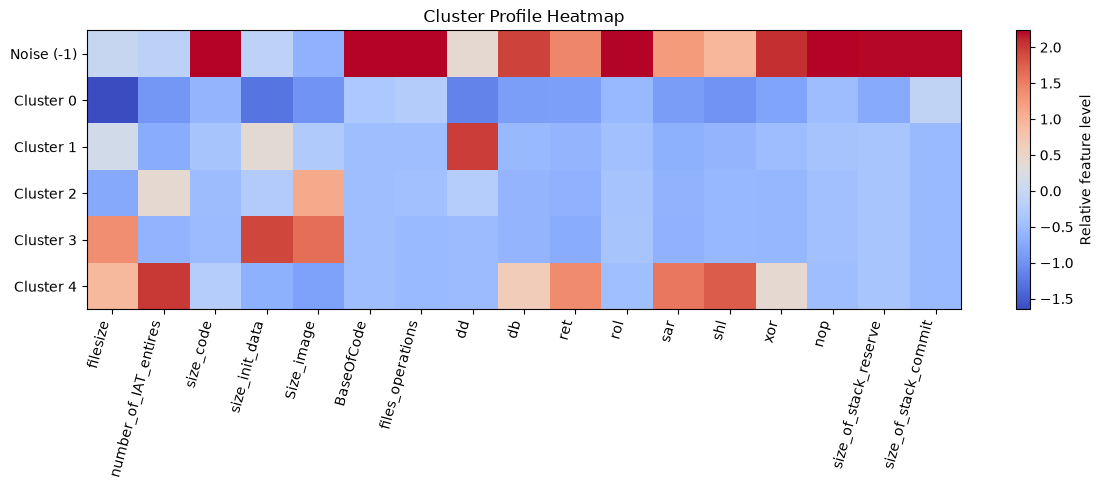

In [849]:
cluster_profile = X.copy()
cluster_profile["cluster"] = db_labels_f
cluster_profile = cluster_profile.groupby("cluster").mean()

profile_scaled = pd.DataFrame(
    StandardScaler().fit_transform(cluster_profile),
    index=cluster_profile.index,
    columns=cluster_profile.columns
)

plt.figure(figsize=(12, 5))
plt.imshow(profile_scaled, aspect='auto', cmap='coolwarm')
plt.colorbar(label='Relative feature level')
plt.yticks(range(len(profile_scaled.index)),
           [f'Cluster {i}' if i != -1 else 'Noise (-1)' for i in profile_scaled.index])
plt.xticks(range(len(profile_scaled.columns)), profile_scaled.columns, rotation=75, ha='right')
plt.title('Cluster Profile Heatmap')
plt.tight_layout()
plt.show()

### Interpretation

| Cluster or Noise Group | Distinctive Features | Possible Interpretation | Evidence from Results |
|---|---|---|---|
| Cluster 0 | filesize | This cluster had the majority of the features, meaning filesize  | The heatmap shows a strong correlation for filesize |
| Cluster 1 | dd | part of the virustotal dataset, all must have had similar dd | heatmaps shows a high relative feature level for dd |
| Noise 2 | Size_image | Not really insightful, just outlier features | Highest relative feature level on heatmap, but not even really that high of a level |

# 9. Final Method Comparison and Recommendation



| Method | Main Strength | Main Weakness | Best Use in This Assignment |
|---|---|---|---|
| K-Means | Main strength was locating the dense features | Was not able to meaningfully separate the denser cluster | Best use in this assignment was highlighting outlier features 
| Hierarchical Clustering | Main strength determining cluster features with the linkage analysis | Main weakness was giving misleading silhouette score since the points where so densely clustered the single linkage silhouette score looked disproportionately good | Best use in this assignment was getting an idea for the density of features
| DBSCAN | Main strength was starting to actually break up the dense feature cluster | Main weakness was a lot of data points were lost in noise | Best use in this assignment was understanding which features were contributing the most to the clusters. 

- If I had to recommend a method I would probably not recommend any as they all seemed to do a poor job. I would probably use the DBSCAN to get a better idea of where the noise was coming from in my dataset and then adjust the features I was using to reduce noise. After that I would rerun with k-means since for me that is the easiest to explain and understand and it also had the best cluster separation. There was some limitation in this assignment since the data was skewed heavily towards malware. 

# AI Use Statement
- I used Gemini to get a better understanding of some basic ideas, like understanding different kinds of linkage and then contextualizing some of the data columns, as well as quick questions about methods/functions. I also used Claude to get a better understanding of topics and to help me write some of the code blocks. A lot of the code AI generates is often bloated, so even if I use it, I often go back and remove code that I think is unnecessary or 'nice-to-have' in favor of concise and readable code. I also used Claude to review what I had written in the assignment, it is good at finding inconsistencies or small human-errors. 